In [11]:
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("EIA_API_KEY")
print(API_KEY[:8])

3PgVz7TN


In [12]:
import os
import requests
import pandas as pd

API_KEY = os.getenv("EIA_API_KEY")

url = "https://api.eia.gov/v2/electricity/retail-sales/data/"

params = {
    "api_key": API_KEY,
    "frequency": "annual",
    "data[]": "sales",
    "facets[stateid][]": "VA",
    "facets[sectorid][]": "IND",
    "start": "2010",
    "end": "2024",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc"
}

r = requests.get(url, params=params)
print(r.status_code)
data = r.json()

# inspect structure
print(data.keys())
print(data["response"]["data"][:3])

200
dict_keys(['response', 'request', 'apiVersion', 'ExcelAddInVersion'])
[{'period': '2010', 'stateid': 'VA', 'stateDescription': 'Virginia', 'sectorid': 'IND', 'sectorName': 'industrial', 'sales': '17141.224', 'sales-units': 'million kilowatt hours'}, {'period': '2011', 'stateid': 'VA', 'stateDescription': 'Virginia', 'sectorid': 'IND', 'sectorName': 'industrial', 'sales': '17218.005', 'sales-units': 'million kilowatt hours'}, {'period': '2012', 'stateid': 'VA', 'stateDescription': 'Virginia', 'sectorid': 'IND', 'sectorName': 'industrial', 'sales': '17315.73901', 'sales-units': 'million kilowatt hours'}]


### Data Frame

In [14]:
df = pd.DataFrame(data["response"]["data"])

df["period"] = pd.to_numeric(df["period"])
df["sales"] = pd.to_numeric(df["sales"])

df.head()

,period,stateid,stateDescription,sectorid,sectorName,sales,sales-units
0,2010,VA,Virginia,IND,industrial,17141.22400,million kilowatt hours
1,2011,VA,Virginia,IND,industrial,17218.00500,million kilowatt hours
2,2012,VA,Virginia,IND,industrial,17315.73901,million kilowatt hours
3,2013,VA,Virginia,IND,industrial,17150.37500,million kilowatt hours
4,2014,VA,Virginia,IND,industrial,17700.99299,million kilowatt hours


In [17]:
import plotly.express as px

fig = px.line(
    df,
    x="period",
    y="sales",
    markers=True,
    title="Virginia Industrial Electricity Demand Growth"
)

fig.update_traces(
    line=dict(width=4)
)

fig.update_layout(
    template="simple_white",
    title_font_size=24,
    xaxis_title="Year",
    yaxis_title="Million kWh",
    hovermode="x unified"
)

fig.show()

In [22]:
import os, requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("EIA_API_KEY")

BASE_URL = "https://api.eia.gov/v2/electricity/retail-sales/data/"

def get_eia_retail(state="VA", sector="IND", metric="sales", start="2010", end="2024"):
    params = {
        "api_key": API_KEY,
        "frequency": "annual",
        "data[]": metric,
        "facets[stateid][]": state,
        "facets[sectorid][]": sector,
        "start": start,
        "end": end,
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000
    }
    r = requests.get(BASE_URL, params=params)
    print(state, sector, metric, r.status_code)
    data = r.json()
    df = pd.DataFrame(data["response"]["data"])
    df["period"] = pd.to_numeric(df["period"])
    df[metric] = pd.to_numeric(df[metric])
    return df

In [23]:
ind_sales = get_eia_retail("VA", "IND", "sales")
ind_sales[["period", "stateDescription", "sectorName", "sales", "sales-units"]]

VA IND sales 200


,period,stateDescription,sectorName,sales,sales-units
0,2010,Virginia,industrial,17141.22400,million kilowatt hours
1,2011,Virginia,industrial,17218.00500,million kilowatt hours
2,2012,Virginia,industrial,17315.73901,million kilowatt hours
3,2013,Virginia,industrial,17150.37500,million kilowatt hours
4,2014,Virginia,industrial,17700.99299,million kilowatt hours
5,2015,Virginia,industrial,17537.16500,million kilowatt hours
6,2016,Virginia,industrial,17648.01401,million kilowatt hours
7,2017,Virginia,industrial,17168.82000,million kilowatt hours
8,2018,Virginia,industrial,17736.93599,million kilowatt hours
9,2019,Virginia,industrial,17598.24699,million kilowatt hours


In [24]:
sectors = {
    "RES": "Residential",
    "COM": "Commercial",
    "IND": "Industrial",
    "TRA": "Transportation",
    "ALL": "All sectors"
}

sector_dfs = []

for code, name in sectors.items():
    temp = get_eia_retail("VA", code, "sales")
    temp["sector_label"] = name
    sector_dfs.append(temp)

va_all_sectors = pd.concat(sector_dfs, ignore_index=True)

VA RES sales 200
VA COM sales 200
VA IND sales 200
VA TRA sales 200
VA ALL sales 200


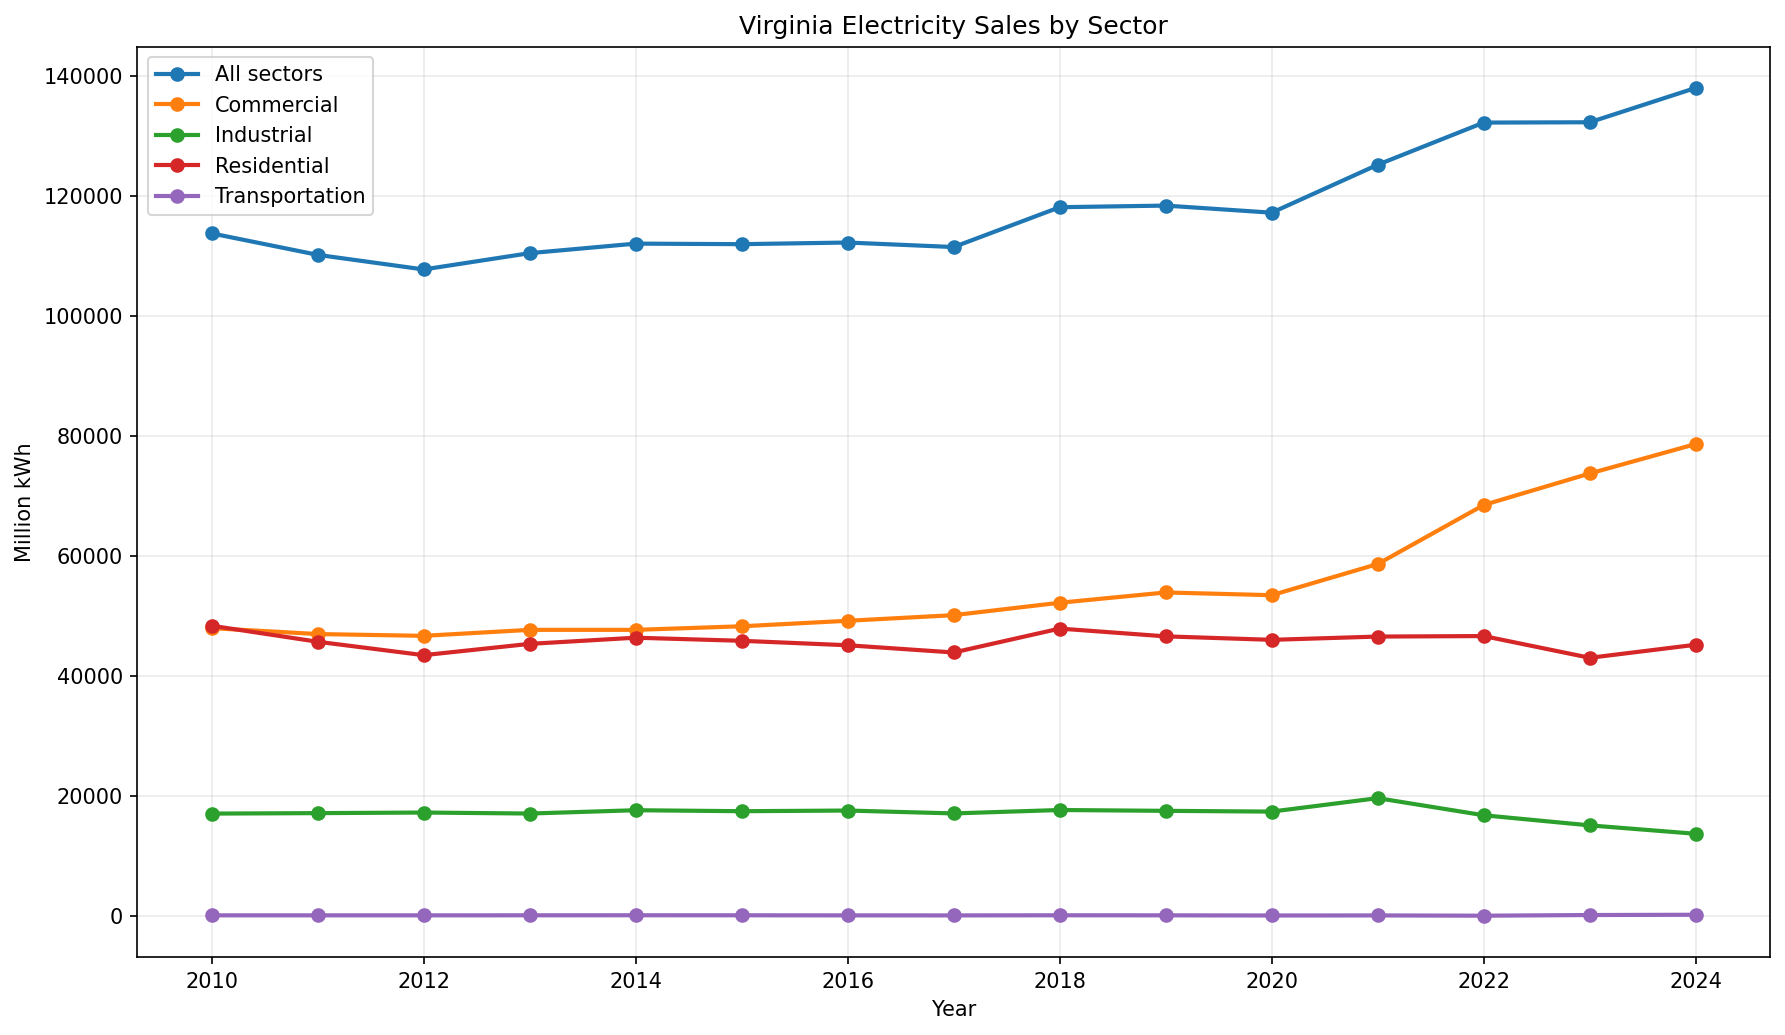

In [25]:
plt.figure(figsize=(12,7), dpi=150)

for name, group in va_all_sectors.groupby("sector_label"):
    plt.plot(group["period"], group["sales"], marker="o", linewidth=2, label=name)

plt.title("Virginia Electricity Sales by Sector")
plt.xlabel("Year")
plt.ylabel("Million kWh")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

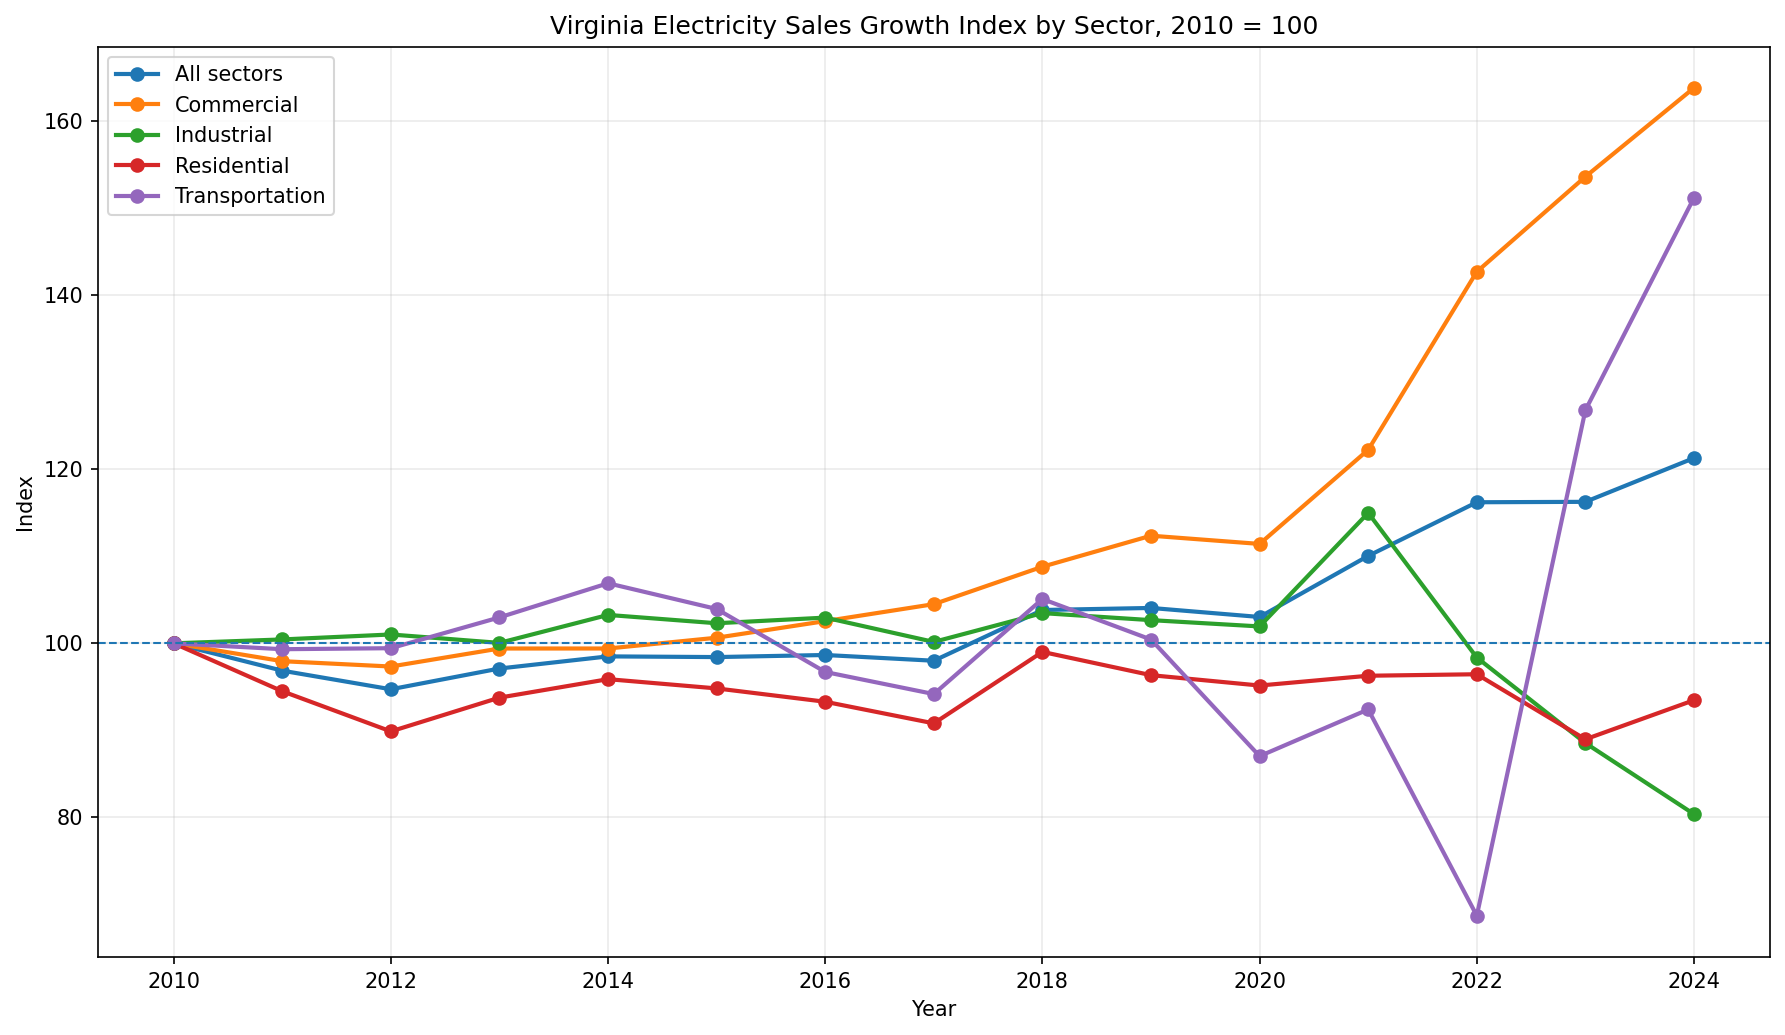

In [26]:
norm = va_all_sectors.copy()

norm["index_2010"] = norm.groupby("sector_label")["sales"].transform(lambda x: x / x.iloc[0] * 100)

plt.figure(figsize=(12,7), dpi=150)

for name, group in norm.groupby("sector_label"):
    plt.plot(group["period"], group["index_2010"], marker="o", linewidth=2, label=name)

plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Virginia Electricity Sales Growth Index by Sector, 2010 = 100")
plt.xlabel("Year")
plt.ylabel("Index")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
states = {
    "VA": "Virginia",
    "MD": "Maryland",
    "NC": "North Carolina",
    "PA": "Pennsylvania",
    "US": "United States"
}

state_dfs = []

for code, name in states.items():
    temp = get_eia_retail(code, "IND", "sales")
    temp["state_label"] = name
    state_dfs.append(temp)

ind_by_state = pd.concat(state_dfs, ignore_index=True)

VA IND sales 200
MD IND sales 200
NC IND sales 200
PA IND sales 200
US IND sales 200


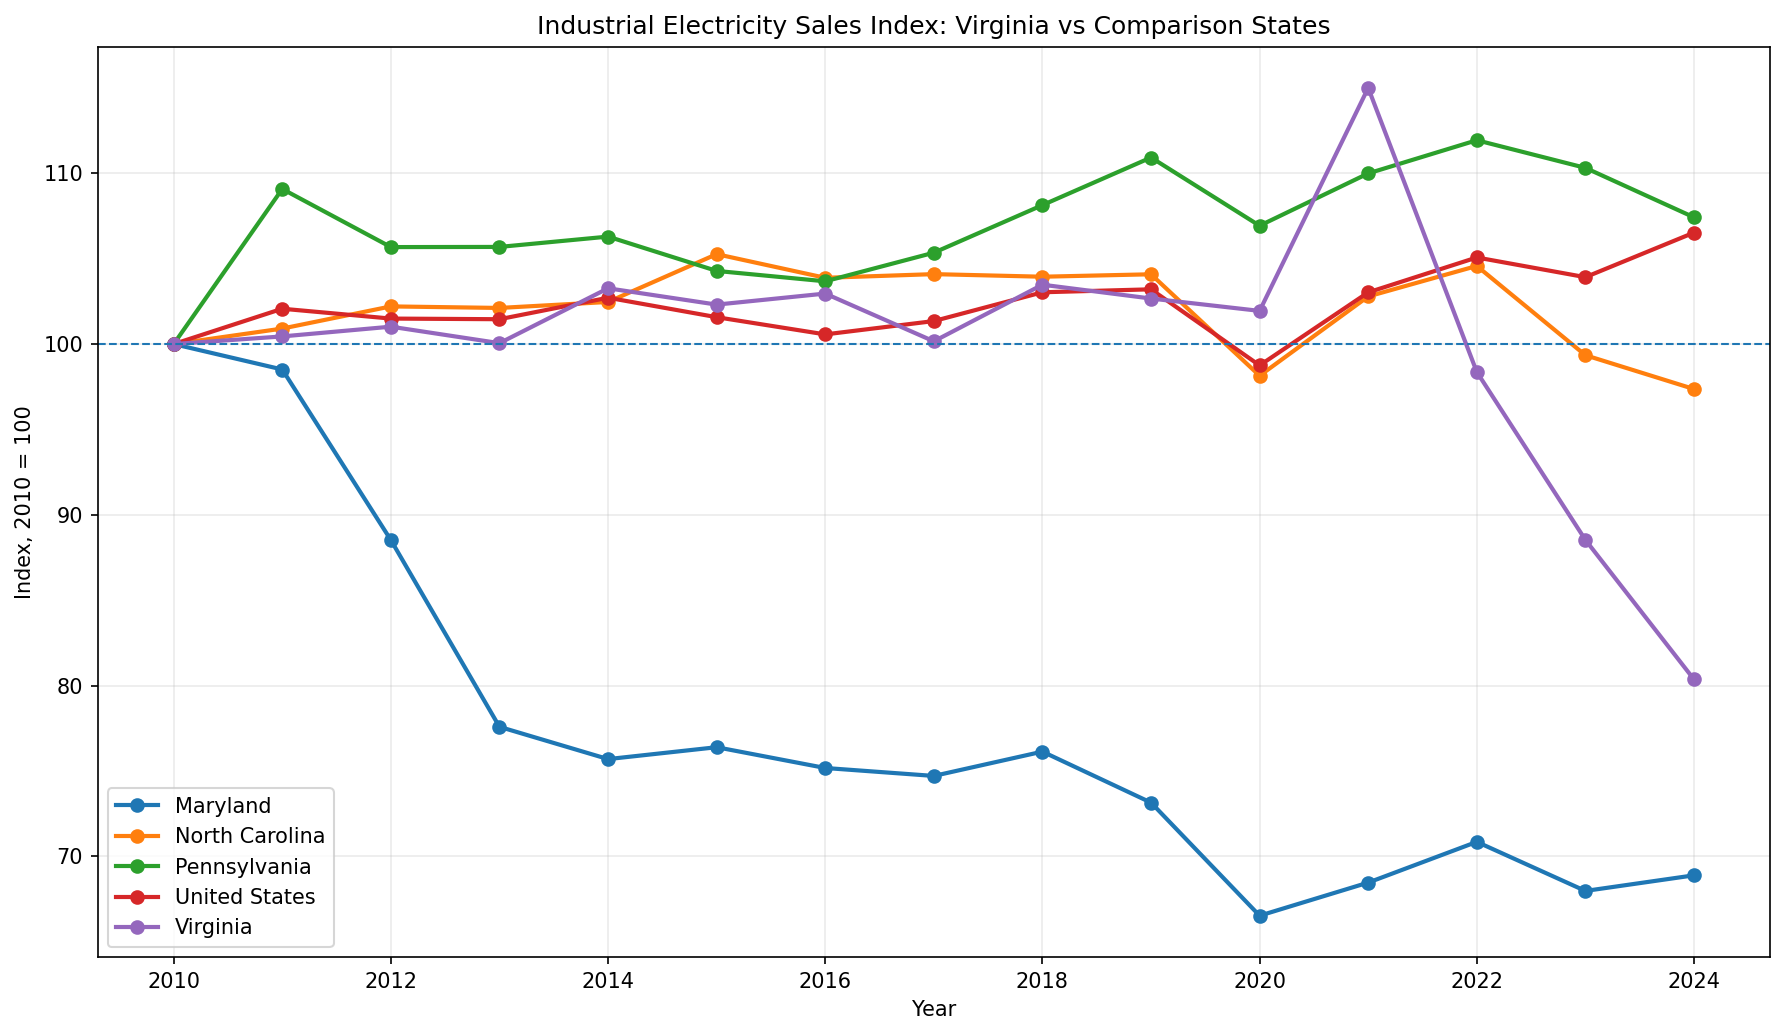

In [28]:
plt.figure(figsize=(12,7), dpi=150)

for name, group in ind_by_state.groupby("state_label"):
    group = group.sort_values("period")
    group["indexed_sales"] = group["sales"] / group["sales"].iloc[0] * 100
    plt.plot(group["period"], group["indexed_sales"], marker="o", linewidth=2, label=name)

plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Industrial Electricity Sales Index: Virginia vs Comparison States")
plt.xlabel("Year")
plt.ylabel("Index, 2010 = 100")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
metrics = ["sales", "customers", "revenue", "price"]
metric_dfs = []

for metric in metrics:
    temp = get_eia_retail("VA", "IND", metric)
    temp["metric"] = metric
    temp = temp.rename(columns={metric: "value"})
    metric_dfs.append(temp[["period", "metric", "value"]])

va_ind_metrics = pd.concat(metric_dfs, ignore_index=True)

VA IND sales 200
VA IND customers 200
VA IND revenue 200
VA IND price 200


In [30]:
metrics = ["sales", "customers", "revenue", "price"]
metric_dfs = []

for metric in metrics:
    temp = get_eia_retail("VA", "IND", metric)
    temp["metric"] = metric
    temp = temp.rename(columns={metric: "value"})
    metric_dfs.append(temp[["period", "metric", "value"]])

va_ind_metrics = pd.concat(metric_dfs, ignore_index=True)


VA IND sales 200
VA IND customers 200
VA IND revenue 200
VA IND price 200


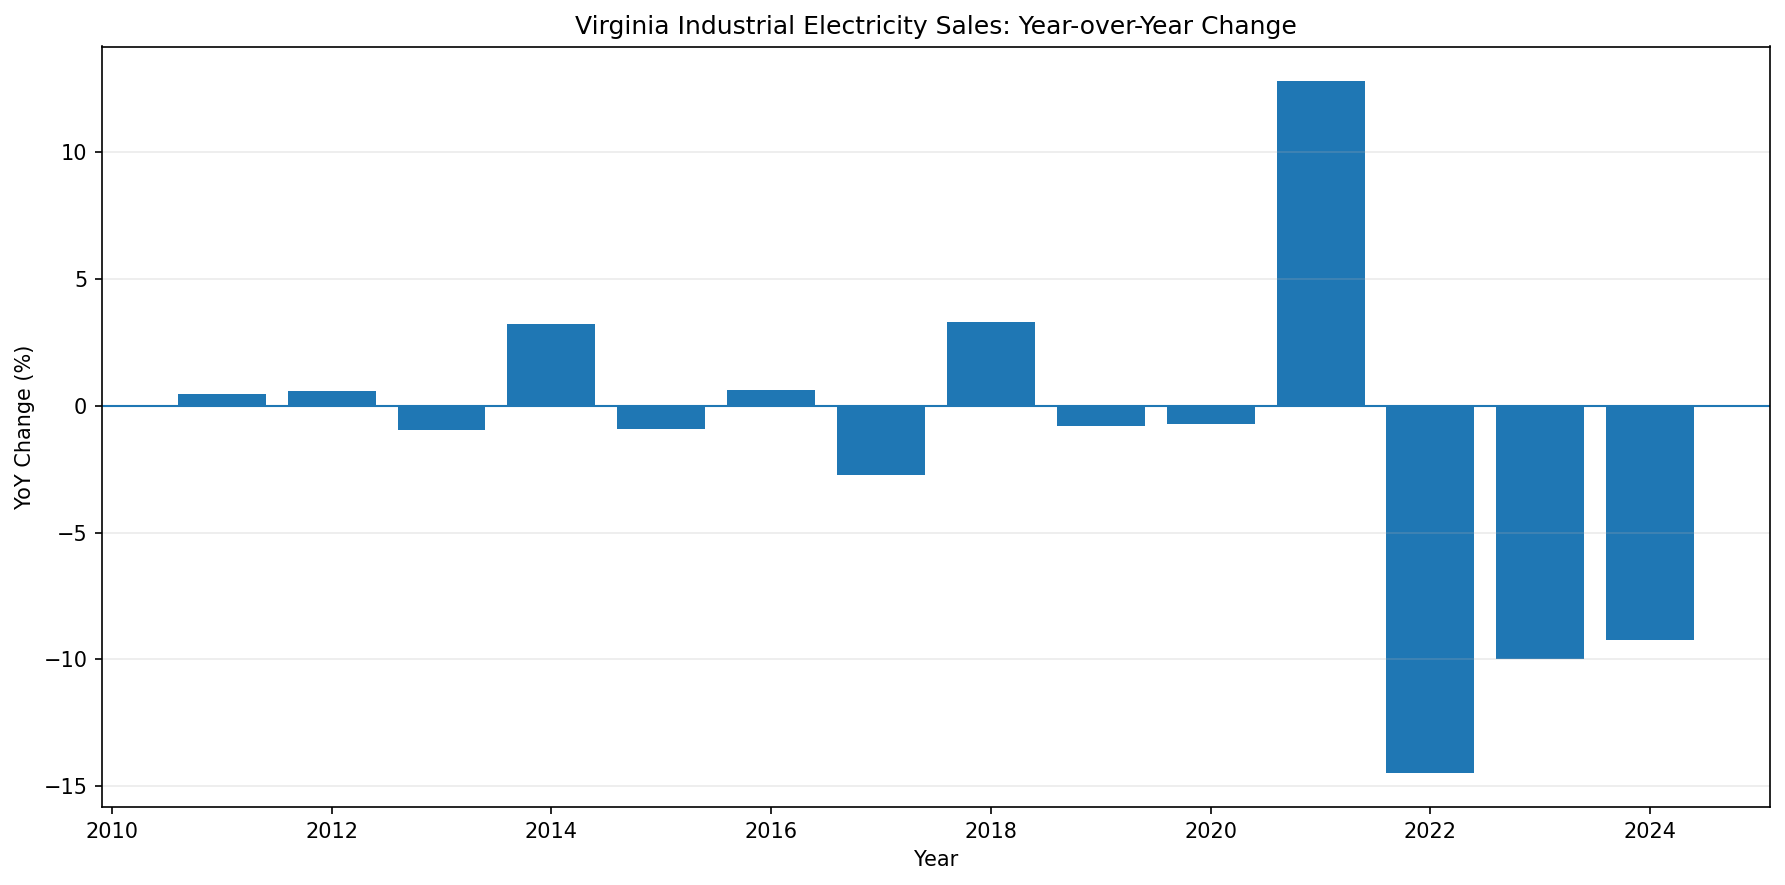

In [31]:
ind_sales = ind_sales.sort_values("period")
ind_sales["yoy_pct"] = ind_sales["sales"].pct_change() * 100

plt.figure(figsize=(12,6), dpi=150)
plt.bar(ind_sales["period"], ind_sales["yoy_pct"])
plt.axhline(0, linewidth=1)

plt.title("Virginia Industrial Electricity Sales: Year-over-Year Change")
plt.xlabel("Year")
plt.ylabel("YoY Change (%)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [32]:
va_compare = va_all_sectors[
    va_all_sectors["sector_label"].isin(
        ["Commercial","Industrial"]
    )
]

In [33]:
for name, group in va_compare.groupby("sector_label"):
    growth = (
        group["sales"].iloc[-1] /
        group["sales"].iloc[0] - 1
    ) * 100

    print(name, growth)

Commercial 63.854296153117
Industrial -19.635085569151876
